In [1]:
!pip install -q opencv-python-headless numpy matplotlib scipy

import subprocess, os, sys

REPO_URL  = "https://github.com/infi9itea/h-orb-vo"
REPO_DIR  = "h-orb-vo"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

sys.path.insert(0, REPO_DIR)
print("Repo ready:", os.listdir(REPO_DIR))

Cloning into 'h-orb-vo'...


Repo ready: ['vo_pipeline.py', 'LICENSE', 'pose_estimator.py', 'datasets.py', 'visualization.py', 'feature_tracker.py', 'test_vo.py', 'metrics.py', 'vo_demo.ipynb', 'README.md', 'trajectory.py', '.git', 'main.py', '.gitignore', 'requirements.txt']


In [2]:
import numpy as np
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image as IPImage
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from vo_pipeline   import MonocularVO, VOConfig
from feature_tracker import FeatureTracker, TrackerConfig
from metrics       import compute_ate, compute_rpe
from visualization import (
    save_harris_corners, save_feature_matches,
    plot_trajectory_2d, plot_error_per_frame,
    plot_inliers_per_frame, plot_matches_per_frame,
    plot_ate_rpe, print_metrics,
)

OUT = Path("vo_outputs")
OUT.mkdir(exist_ok=True)
print('Imports OK')

Imports OK


In [3]:
import glob
import os

IMAGE_DIR = "/kaggle/input/datasets/hocop1/kitti-odometry/sequences/10/image_2"
POSES_FILE = "/kaggle/input/datasets/hocop1/kitti-odometry/poses/10.txt" 
CALIB_FILE = "/kaggle/input/datasets/hocop1/kitti-odometry/sequences/10/calib.txt"

image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.png")))
N_FRAMES = len(image_paths)
print(f"Found {N_FRAMES} images in {IMAGE_DIR}")

K = np.array([[718.856, 0.0, 607.192],
              [0.0, 718.856, 185.215],
              [0.0, 0.0, 1.0]], dtype=np.float64)

if os.path.exists(CALIB_FILE):
    with open(CALIB_FILE, 'r') as f:
        for line in f:
            if line.startswith('P2:'):
                P2 = np.array([float(x) for x in line.strip().split()[1:]]).reshape(3, 4)
                K = P2[:3, :3]
                break

gt_positions = []
has_gt = os.path.exists(POSES_FILE)
if has_gt:
    with open(POSES_FILE, 'r') as f:
        for line in f:
            pose_matrix = np.array([float(x) for x in line.strip().split()]).reshape(3, 4)
            gt_positions.append(pose_matrix[:, 3])
else:
    print("Warning: Poses not found. ATE/RPE metrics will fail and VO will suffer from scale drift.")
    gt_positions = [np.zeros(3)] * N_FRAMES

gt_arr = np.array(gt_positions)
print(f"Ready to process {N_FRAMES} real frames.")

Found 1201 images in /kaggle/input/datasets/hocop1/kitti-odometry/sequences/10/image_2
Ready to process 1201 real frames.


In [4]:
cfg = VOConfig(verbose=False)
cfg.tracker.detector     = 'harris'
cfg.tracker.max_features = 400
cfg.use_gt_scale         = has_gt

vo = MonocularVO(K, cfg)

for i, img_path in enumerate(image_paths):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    gt_pos = gt_arr[i] if i < len(gt_arr) else np.zeros(3)
    
    vo.process_frame(img, gt_pos)
    
    if (i + 1) % 200 == 0 or (i + 1) == N_FRAMES:
        print(f"Processed {i + 1}/{N_FRAMES} frames...")

traj    = vo.trajectory
est_pos = traj.estimated_positions()
n       = min(len(est_pos), len(gt_arr))
est_pos = est_pos[:n]
gt_pos_n = gt_arr[:n]

print(f'\nFinished processing {n} frames.')
print(f'Est pos range X: [{est_pos[:,0].min():.2f}, {est_pos[:,0].max():.2f}]')
print(f'GT  pos range X: [{gt_pos_n[:,0].min():.2f}, {gt_pos_n[:,0].max():.2f}]')

Processed 200/1201 frames...
Processed 400/1201 frames...
Processed 600/1201 frames...
Processed 800/1201 frames...
Processed 1000/1201 frames...
Processed 1200/1201 frames...
Processed 1201/1201 frames...

Finished processing 1201 frames.
Est pos range X: [-523.16, 0.07]
GT  pos range X: [0.00, 670.85]


In [ ]:
ate = compute_ate(est_pos, gt_pos_n)

Rs_est = [f.R for f in traj.frames[:n]]
ts_est = [f.t for f in traj.frames[:n]]
rpe = compute_rpe(
    Rs_est, ts_est,
    [np.eye(3)] * n,
    [p.reshape(3,1) for p in gt_pos_n]
)

print('\n── Metric Table ─────────────────────────────────')
rows = [
    ('ATE RMSE',           f"{ate['rmse']:.4f} m"),
    ('ATE Mean',           f"{ate['mean']:.4f} m"),
    ('ATE Std',            f"{ate['std']:.4f} m"),
    ('ATE Max',            f"{ate['max']:.4f} m"),
    ('RPE Trans RMSE',     f"{rpe['trans_rmse']:.4f} m"),
    ('RPE Trans Mean',     f"{rpe['trans_mean']:.4f} m"),
    ('RPE Rot RMSE',       f"{rpe['rot_rmse']:.4f} °"),
    ('RPE Rot Mean',       f"{rpe['rot_mean']:.4f} °"),
    ('Total frames',       str(n)),
    ('Avg inliers/frame',  f"{np.mean(vo.inlier_counts):.1f}"),
    ('Avg matches/frame',  f"{np.mean(vo.match_counts):.1f}"),
]
for k, v in rows:
    print(f'  {k:<22} {v}')

=== Synthetic-499 ===
  ATE  RMSE:       23.8785 m
  ATE  Mean+-Std:  20.5155 +- 12.2187 m
  RPE  Trans RMSE: 1.1400 m
  RPE  Rot   RMSE: 0.8386 deg


── Metric Table ─────────────────────────────────
  ATE RMSE               23.8785 m
  ATE Mean               20.5155 m
  ATE Std                12.2187 m
  ATE Max                54.7186 m
  RPE Trans RMSE         1.1400 m
  RPE Trans Mean         1.0097 m
  RPE Rot RMSE           0.8386 °
  RPE Rot Mean           0.4913 °
  Total frames           1201
  Avg inliers/frame      68.1
  Avg matches/frame      90.8


Frame 0: 109 Harris corners   |   Frame 1: 111 Harris corners
Saved Harris corners -> vo_outputs/harris_frame0.png


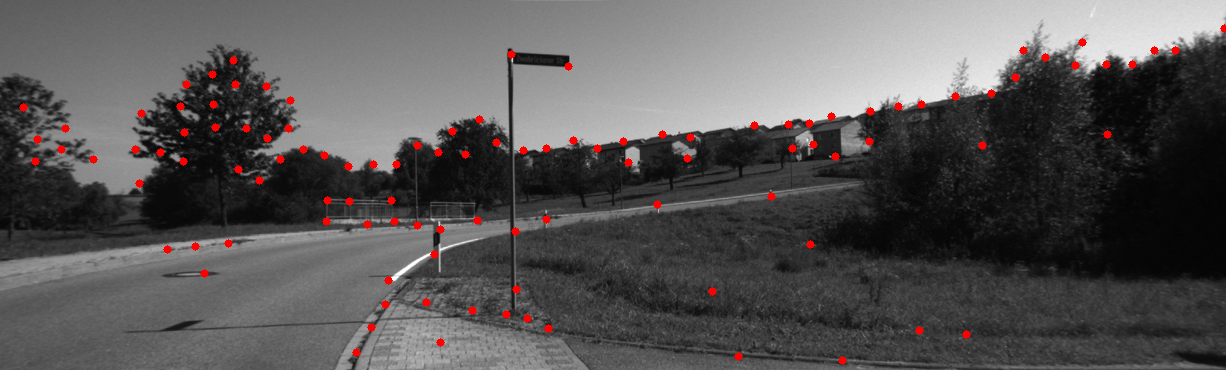

In [6]:
tracker  = vo.tracker
img0 = cv2.imread(image_paths[0], cv2.IMREAD_GRAYSCALE)
img1 = cv2.imread(image_paths[1], cv2.IMREAD_GRAYSCALE)

pts0 = tracker.detect(img0)
pts1 = tracker.detect(img1)
print(f'Frame 0: {len(pts0)} Harris corners   |   Frame 1: {len(pts1)} Harris corners')

harris_path = str(OUT / 'harris_frame0.png')
save_harris_corners(img0, pts0, save_path=harris_path)
display(IPImage(harris_path))

Tracked: 108 / 109 points
Saved feature matches -> vo_outputs/feature_matches_0_1.png


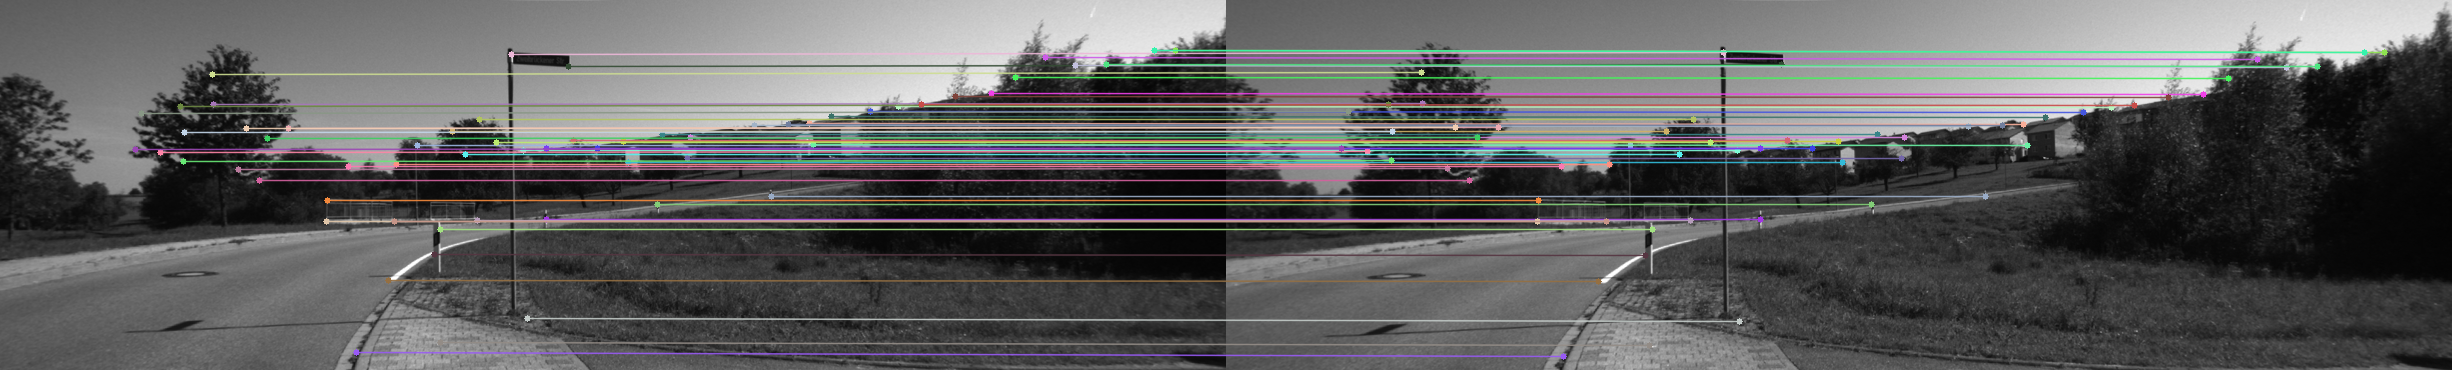

In [7]:
_, pts1_tracked, good = tracker.track(img0, img1, pts0)
pts0_tracked = pts0[:len(pts1_tracked)]
print(f'Tracked: {good.sum()} / {len(pts0)} points')

matches_path = str(OUT / 'feature_matches_0_1.png')
save_feature_matches(img0, img1, pts0_tracked, pts1_tracked,
                     save_path=matches_path, max_lines=60)
display(IPImage(matches_path))

Saved inliers plot -> vo_outputs/inliers_per_frame.png


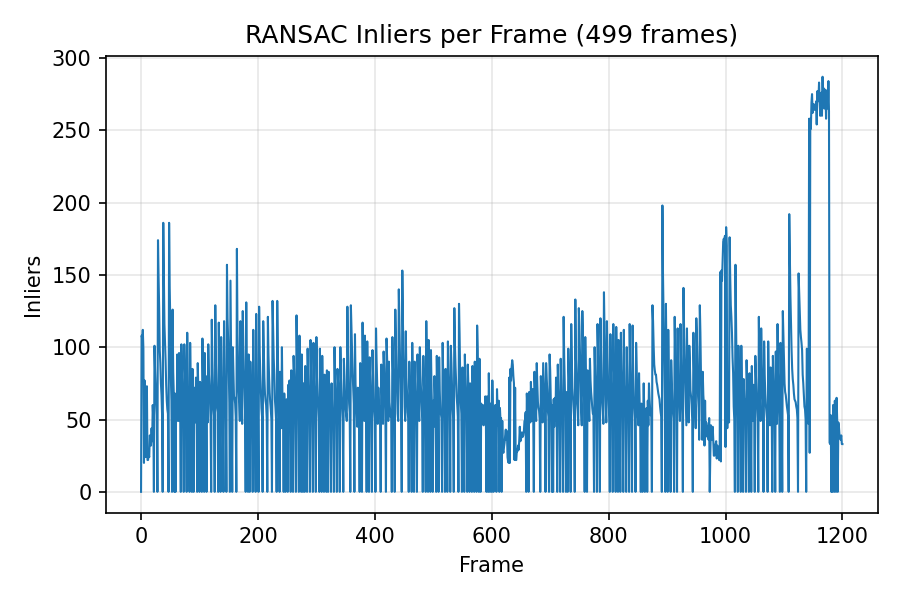

In [8]:
inliers_path = str(OUT / 'inliers_per_frame.png')
plot_inliers_per_frame(vo.inlier_counts,
                       title='RANSAC Inliers per Frame (499 frames)',
                       save_path=inliers_path)
display(IPImage(inliers_path))

Saved matches plot -> vo_outputs/matches_per_frame.png


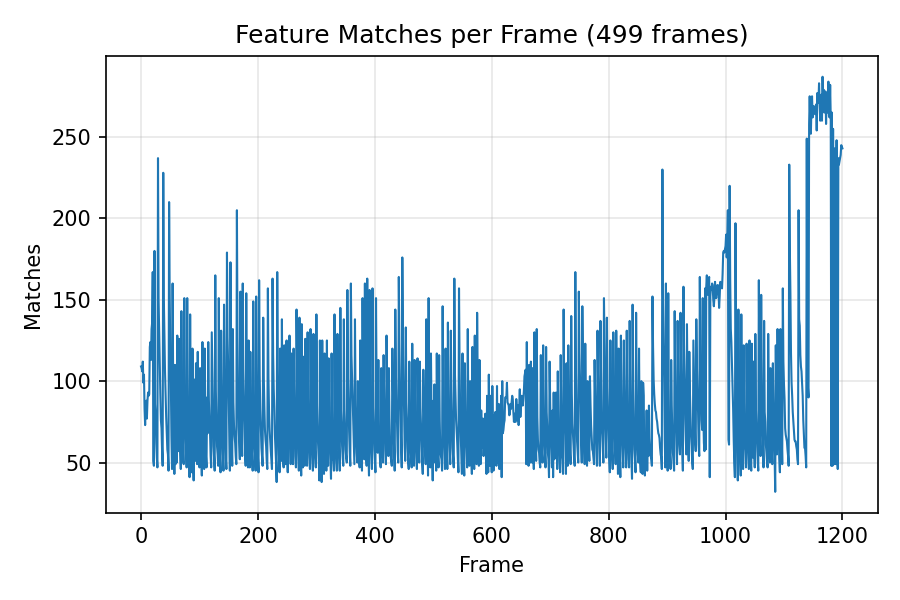

In [9]:
matches_plot_path = str(OUT / 'matches_per_frame.png')
plot_matches_per_frame(vo.match_counts,
                       title='Feature Matches per Frame (499 frames)',
                       save_path=matches_plot_path)
display(IPImage(matches_plot_path))

Saved error plot -> vo_outputs/trajectory_error.png


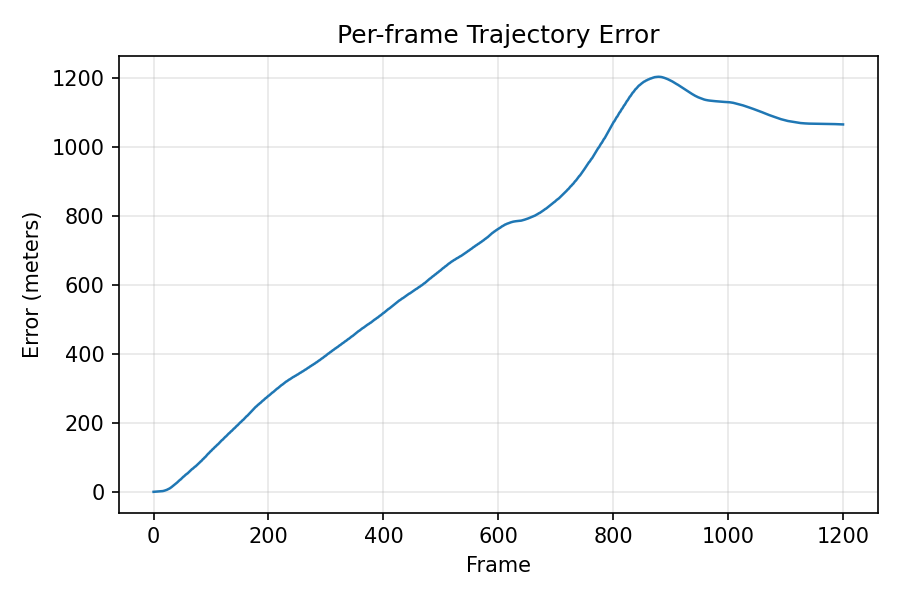

In [10]:
error_path = str(OUT / 'trajectory_error.png')
plot_error_per_frame(est_pos, gt_pos_n,
                     title='Per-frame Trajectory Error',
                     save_path=error_path)
display(IPImage(error_path))

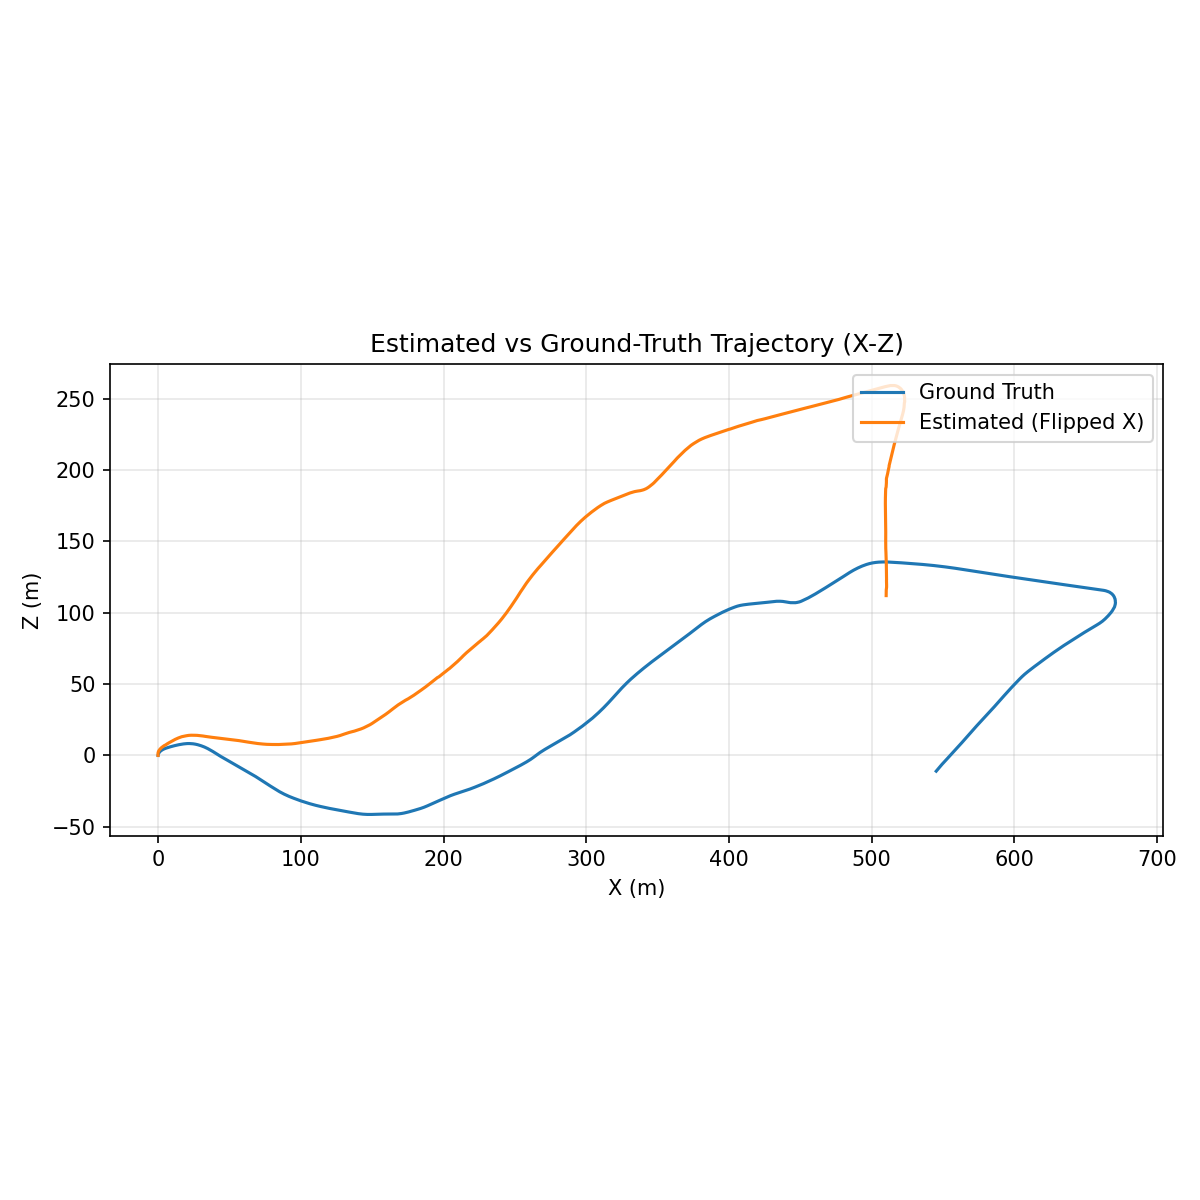

In [11]:
traj_path = str(OUT / 'trajectory_xz.png')
plot_trajectory_2d(est_pos, gt_pos_n,
                   title='Estimated vs Ground-Truth Trajectory (X-Z)',
                   save_path=traj_path)
display(IPImage(traj_path))

Saved metrics plot -> vo_outputs/ate_rpe.png


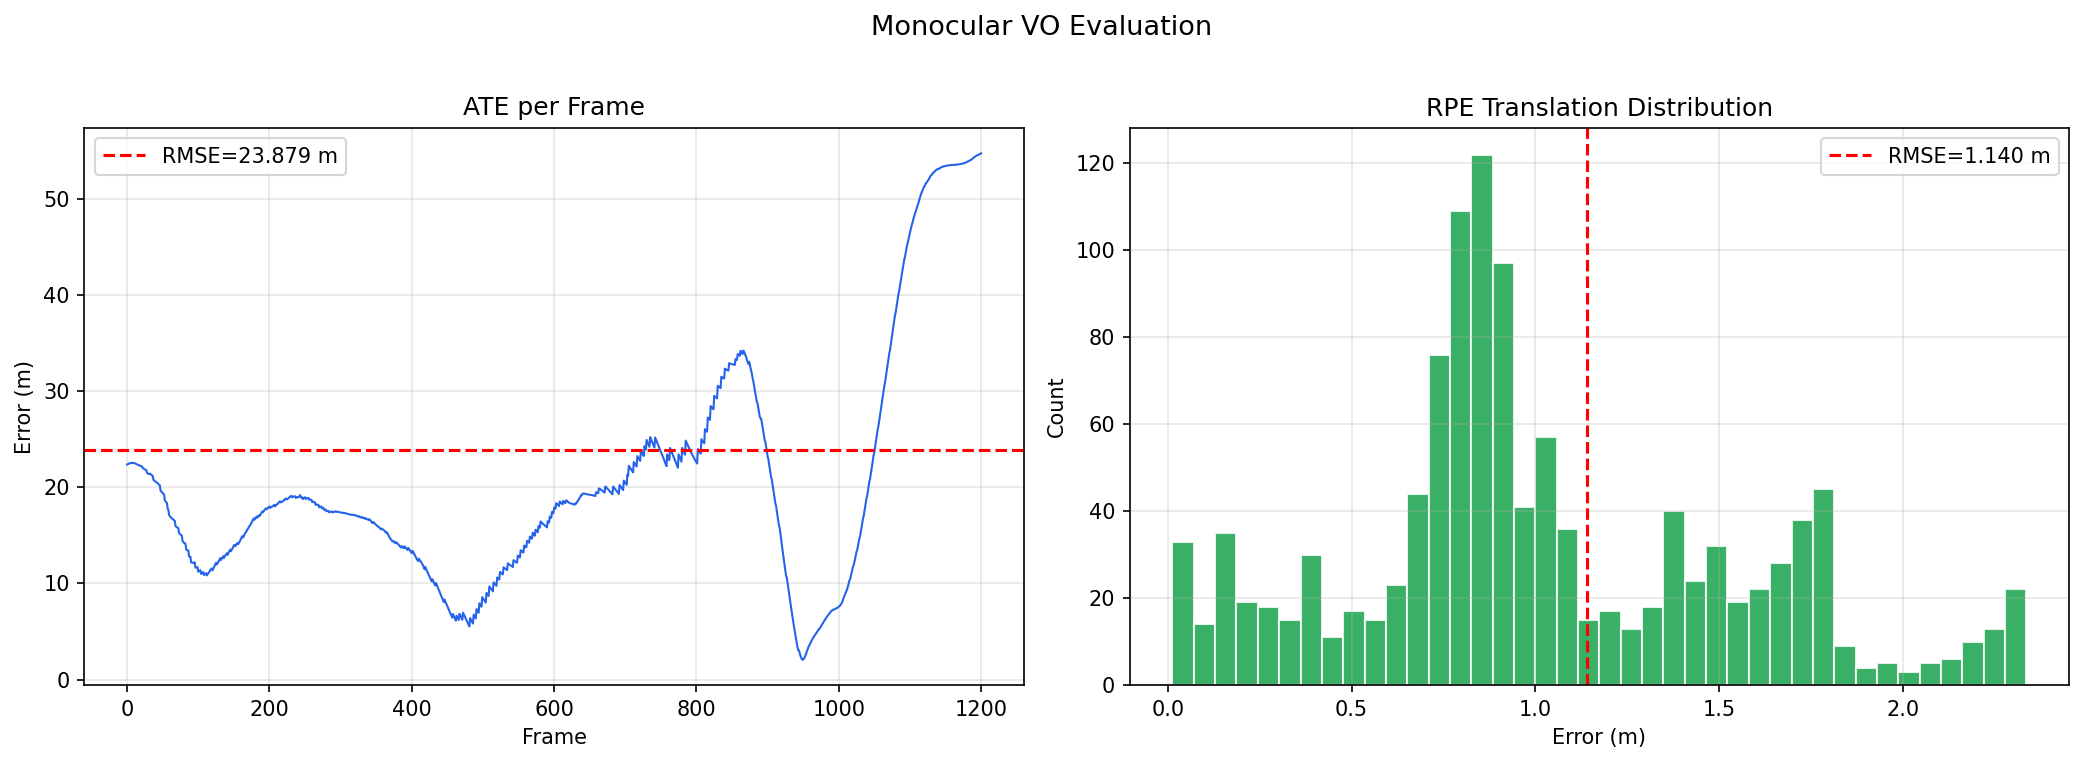

In [12]:
ate_rpe_path = str(OUT / 'ate_rpe.png')
plot_ate_rpe(ate, rpe, save_path=ate_rpe_path)
display(IPImage(ate_rpe_path))